In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Generate data

In [3]:
use_existing_data = False

rn.seed(100)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = sparse.COO(data)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = sparse.COO(data)

# Fit with BPTF

In [4]:
n_components = 50
max_iter = 500
mask = None
device = 'cuda'
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 0]  min uttkrp_DK = 2.297e+05
[mode 0]  min new rate = 2.297e+05   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 1]  min uttkrp_DK = 3.078e+03
[mode 1]  min new rate = 3.078e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 2.764e+04
[mode 2]  min new rate = 2.764e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 2.134e+04
[mode 3]  min new rate = 2.134e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


...

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 1.733e-02
[mode 3]  min new rate = 1.388e-01   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 4]  min uttkrp_DK = 3.958e+03
[mode 4]  min new rate = 3.958e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


100%|██████████████████████████████████████████████████████████████████████████████████████████| 500/500 [2:33:35<00:00, 18.50s/it]

100%|██████████████████████████████████████████████████████████████████████████████████████████| 500/500 [2:33:35<00:00, 18.43s/it]

BPTF(data_shape=(200, 200, 20, 24, 3), n_components=50)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2805367241.2853203, 85725026.4817331, 173133029.44634402, 201441736.811899, 203622316.4150229, 203714437.26869065, 203728133.3405754, 203732891.12958243, 203735561.62262636, 203737567.3132388, 203739357.5633118, 203740733.07846484, 203741734.7735538, 203742635.19356355, 203743488.36222535, 203744119.2356918, 203744720.25543603, 203745258.93949297, 203745705.455877, 203746112.21048716, 203746490.88639724, 203746846.64999348, 203747190.48013917, 203747526.04629883, 203747862.3903603, 203748208.26754662, 203748577.3851154, 203749009.97987747, 203749442.30441058, 203749700.26739764, 203749963.31067148, 203750282.43381277, 203750694.07137695, 203751049.17045242, 203751294.87556487, 203751620.830823, 203751958.32496715, 203752118.76732615, 203752278.36317924, 203752474.29423615, 203752726.1431483, 203753049.98592567, 203753223.3567213, 203753324.34612152, 203753437.31097755, 203753566.25133756, 2

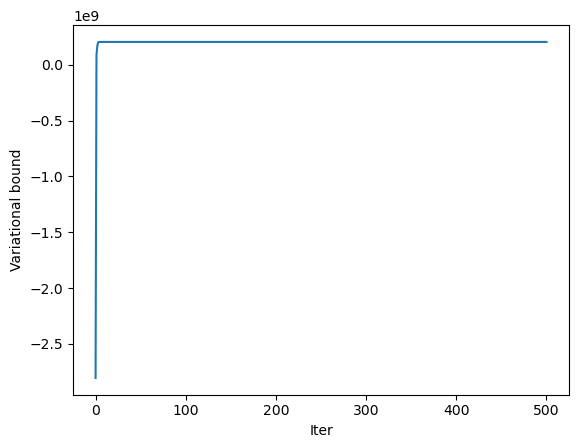

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch.fit(data, mask = None, max_iter = max_iter, verbose=False, tol=tol)

# Check similarity

In [7]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

Frobenius norm relative difference: 0.0028281601969921046
Proportion of elements with difference greater than 0.05 = 0.007532170138888889


tensor(0.3420, device='cuda:0') tensor(0.1216, device='cuda:0') tensor(84.9561, device='cuda:0')


tensor([ 1004, 44202,  4332,  3539, 20326, 30479,  6212,     0,    16,  3080,
         4581, 33769,   165, 57095, 48673, 27005, 37806,   191, 31639, 33877,
            0, 14213, 31347,   302], device='cuda:0')


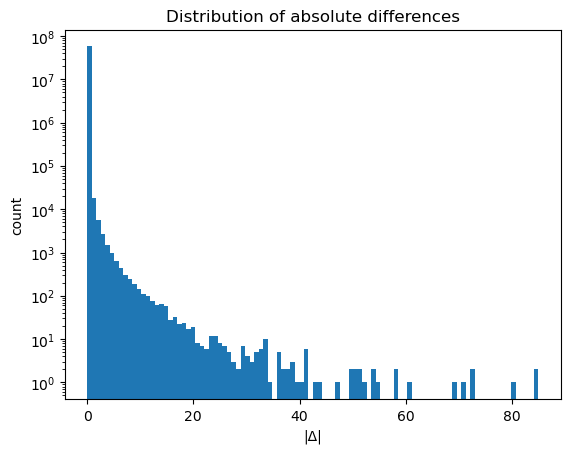

In [8]:
# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month